In [3]:
import os
import glob
import numpy as np
import argparse
import cv2

import mahotas

In [39]:
import tqdm
import glob
import os
import matplotlib.pyplot as plt

In [59]:
path = "Original ROI images/healthy"

image_paths = glob.glob(os.path.join(path, "*.tif")) 

if not image_paths:
    raise ValueError(f"Nenhuma imagem encontrada em {path}")

root_dir = path if os.path.isdir(path) else os.path.dirname(path)
output_root = os.path.join("masks")
output_dirs = {
    "limiarizacao_simples": os.path.join(output_root, "limiarizacao_simples"),
    "limiarizacao_adaptativa": os.path.join(output_root, "limiarizacao_adaptativa"),
    "otsu": os.path.join(output_root, "otsu"),
    "masks_ref": os.path.join(output_root, "masks_ref/healthy")
}
for output_dir in output_dirs.values():
    os.makedirs(output_dir, exist_ok=True)

In [30]:
for image_path in image_paths:
    
    image_name = os.path.splitext(os.path.basename(image_path))[0]
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Falha ao ler a imagem: {image_path}")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    _, thresh_simple = cv2.threshold(blurred, 155, 255, cv2.THRESH_BINARY)
    thresh_adaptive = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV,
        11,
        4,
    )
    T = mahotas.thresholding.otsu(blurred)
    thresh_otsu = gray.copy()
    thresh_otsu[thresh_otsu > T] = 255
    thresh_otsu[thresh_otsu < 255] = 0
    thresh_otsu = cv2.bitwise_not(thresh_otsu)

    cv2.imwrite(
        os.path.join(output_dirs["limiarizacao_simples"], f"{image_name}.png"),
        thresh_simple,
    )
    cv2.imwrite(
        os.path.join(output_dirs["limiarizacao_adaptativa"], f"{image_name}.png"),
        thresh_adaptive,
    )
    cv2.imwrite(
        os.path.join(output_dirs["otsu"], f"{image_name}.png"),
        thresh_otsu,
    )

    print(f"Processada: {image_path}")
print(f"Máscaras salvas em: {output_root}")

Processada: Original ROI images/healthy\healthy-01-roi1.tif
Processada: Original ROI images/healthy\healthy-01-roi2.tif
Processada: Original ROI images/healthy\healthy-01-roi3.tif
Processada: Original ROI images/healthy\healthy-01-roi4.tif
Processada: Original ROI images/healthy\healthy-01-roi5.tif
Processada: Original ROI images/healthy\healthy-02-roi1.tif
Processada: Original ROI images/healthy\healthy-02-roi2.tif
Processada: Original ROI images/healthy\healthy-02-roi3.tif
Processada: Original ROI images/healthy\healthy-02-roi4.tif
Processada: Original ROI images/healthy\healthy-02-roi5.tif
Processada: Original ROI images/healthy\healthy-03-roi1.tif
Processada: Original ROI images/healthy\healthy-03-roi2.tif
Processada: Original ROI images/healthy\healthy-03-roi3.tif
Processada: Original ROI images/healthy\healthy-03-roi4.tif
Processada: Original ROI images/healthy\healthy-04-roi1.tif
Processada: Original ROI images/healthy\healthy-04-roi2.tif
Processada: Original ROI images/healthy\

# DICE calculus

In [32]:
def dice_score(mask_real, mask_pred):
    intersection = np.sum(mask_real * mask_pred)
    return (2. * intersection) / (np.sum(mask_real) + np.sum(mask_pred))

In [ ]:
for method, output_dir in output_dirs.items():
    dice_scores = []
    for image_path in image_paths:
        image_name = os.path.splitext(os.path.basename(image_path))[0]
        mask_real_path = os.path.join("masks_ref/healthy", f"{image_name}.png")
        mask_pred_path = os.path.join(output_dir, f"{image_name}.png")

        mask_real = cv2.imread(mask_real_path, cv2.IMREAD_GRAYSCALE)
        mask_pred = cv2.imread(mask_pred_path, cv2.IMREAD_GRAYSCALE)

        score = dice_score(mask_real > 0, mask_pred > 0)
        dice_scores.append(score)

    if dice_scores:
        mean_dice = np.mean(dice_scores)
        print(f"Dice score médio para {method}: {mean_dice:.4f}")
    else:
        print(f"Nenhuma máscara válida encontrada para {method}.")

Dice score médio para limiarizacao_simples: 0.1084
Dice score médio para limiarizacao_adaptativa: 0.4596
Dice score médio para otsu: 0.5570


In [62]:
def plot_image_per_method(image_name):
    methods = ["limiarizacao_simples", "limiarizacao_adaptativa", "otsu"]
    fig, axes = plt.subplots(1, len(methods), figsize=(20, 5))

    for i, method in enumerate(methods):
        mask_path = os.path.join(output_dirs[method], f"{image_name}.png")
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        axes[i].imshow(mask, cmap='gray')
        axes[i].set_title(method)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

In [69]:
name = "healthy-04-roi1"  # Substitua pelo nome da imagem desejada

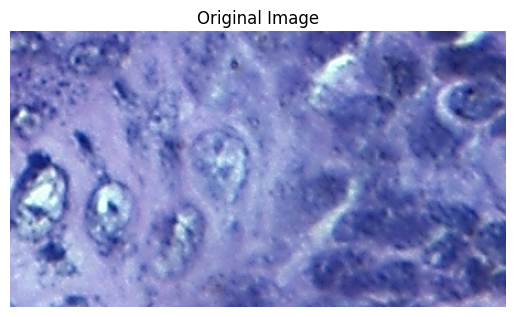

In [70]:
# plot original image
original_image = cv2.imread(os.path.join("Original ROI images", "healthy", f"{name}.tif"))
if original_image is None:
    raise FileNotFoundError(f"Imagem não encontrada: {os.path.join('Original ROI images', 'healthy', f'{name}.tif')}")
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis('off')
plt.show()

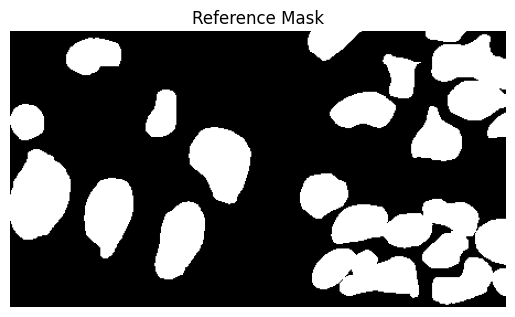

In [73]:
# plot ref image
ref_mask = cv2.imread(os.path.join("masks_ref/healthy", f"{name}.png"), cv2.IMREAD_GRAYSCALE)
plt.imshow(ref_mask, cmap='gray')
plt.title("Reference Mask")
plt.axis('off')
plt.show()

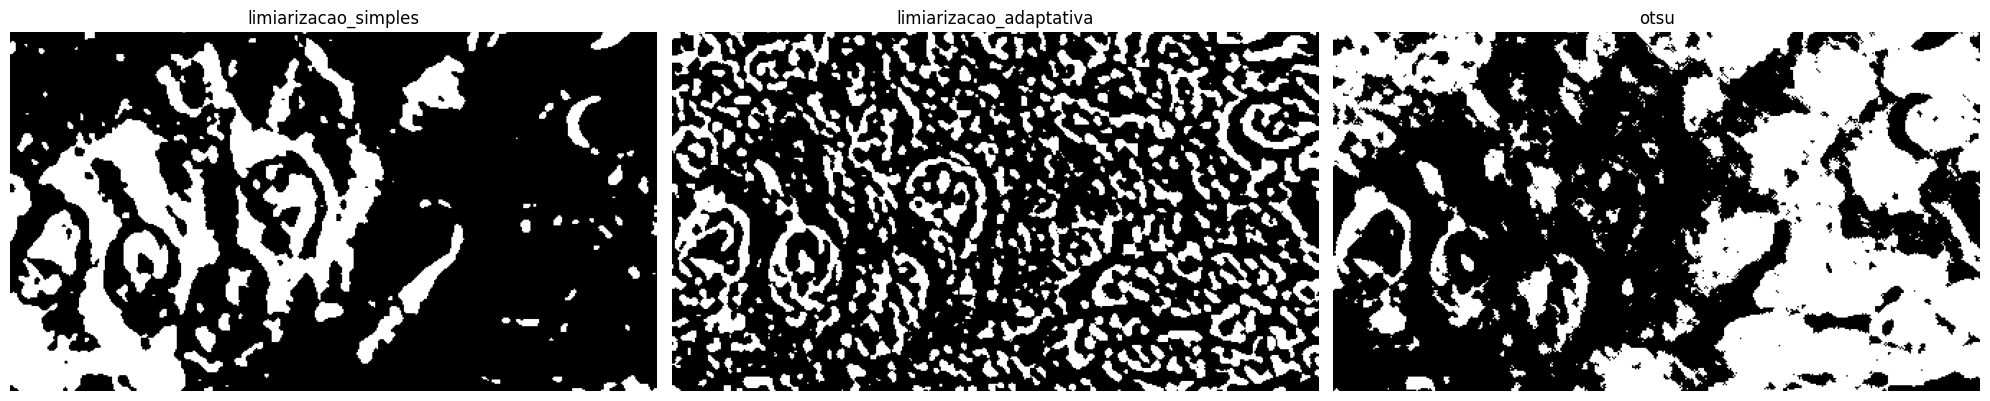

In [72]:
plot_image_per_method(name)  # Substitua "image_1" pelo nome da